# Análisis Exploratorio de Datos (EDA) - Propiedades Físicas de Galaxias MaNGA

**Equipo 61**

## Contexto del Proyecto

Este proyecto tiene como objetivo desarrollar un modelo de aprendizaje profundo capaz de **inferir propiedades físicas de galaxias directamente desde imágenes satelitales**, sin necesidad de realizar todo el procesamiento tradicional que normalmente se requiere para obtener estos datos.

### Origen de los Datos

Los datos provienen del proyecto **MaNGA (Mapping Nearby Galaxies at APO)**, que es parte del **Sloan Digital Sky Survey (SDSS)**. Este conjunto de datos contiene propiedades físicas y estructurales de galaxias cercanas, obtenidas mediante espectroscopía de campo integral (IFU).

### Variables del Conjunto de Datos

Las variables incluyen:

**Variables de identificación y posición:**
- `name`: Identificador único de la galaxia (formato: manga-XXXXX-XXXXX)
- `objra`: Ascensión recta (coordenada celestial en grados)
- `objdec`: Declinación (coordenada celestial en grados)

**Variables morfológicas (CAS):**
- `C`: Concentración - mide qué tan concentrada está la luz en el centro de la galaxia
- `A`: Asimetría - mide la asimetría rotacional de la galaxia
- `S`: Suavidad (Smoothness) - mide la irregularidad de la estructura

**Variables de masa y estructura:**
- `nsa_sersic_mass`: Masa estelar total (en masas solares)
- `LogMass`: Logaritmo de la masa estelar total
- `nsa_sersic_ba`: Relación de eje menor/mayor (elipticidad)
- `nsa_sersic_n`: Índice de Sersic (describe el perfil de brillo)
- `PETRO_TH90`: Radio de Petrosian al 90% de flujo

**Variables de formación estelar y composición:**
- `log_age_mean_LW`: Edad estelar media ponderada por luminosidad (logaritmo)
- `log_ZH_mean_LW`: Metalicidad media ponderada por luminosidad (logaritmo)
- `log_SFR_ssp`: Tasa de formación estelar de SSP (logaritmo)
- `log_SFR_Ha`: Tasa de formación estelar de H-alpha (logaritmo)

**Variables cinemáticas y fotométricas:**
- `vel_sigma_Re`: Dispersión de velocidad al radio efectivo
- `modelMag_r`: Magnitud modelo en banda r

## Objetivo del EDA

En este primer avance realizaremos un **análisis exploratorio exhaustivo** para:
1. Comprender la estructura y calidad de los datos
2. Identificar patrones, tendencias y relaciones entre variables
3. Detectar y manejar valores faltantes, atípicos y problemas de calidad
4. Preparar el conjunto de datos para el desarrollo del modelo de deep learning


In [1]:
# Importación de librerías necesarias
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

---

## 1. Carga y Descripción Inicial del Conjunto de Datos

En esta sección cargamos el archivo CSV y realizamos una inspección inicial para comprender:
- El tamaño del dataset (número de filas y columnas)
- Los tipos de datos de cada variable
- Una vista preliminar de los primeros registros

In [2]:
# Carga del archivo CSV con propiedades físicas de galaxias MaNGA
df = pd.read_csv('inferencia.csv')

# Mostrar las dimensiones del dataset
print(f"DIMENSIONES DEL DATASET")
print(f"Número de galaxias (filas): {df.shape[0]:,}")
print(f"Número de variables (columnas): {df.shape[1]}")

DIMENSIONES DEL DATASET
Número de galaxias (filas): 10,126
Número de variables (columnas): 17


In [3]:
# Vista previa de las primeras 10 filas del dataset
print("\nVISTA PREVIA DEL DATASET (primeras 10 galaxias):\n")
df.head(10)


VISTA PREVIA DEL DATASET (primeras 10 galaxias):



,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,133.3711,57.5984,2.419,0.191,0.26,3.0680e+09,9.4869,0.3353,0.7418,7.8809,8.5793,-0.6862,0.2797,-0.0895,0.7871,16.3824
1,manga-10001-12702,133.6857,57.4803,2.882,0.094,0.01,5.3416e+09,9.7277,0.5082,1.4427,14.1474,8.6074,-0.5342,0.0641,-0.6085,0.7881,16.6850
2,manga-10001-12703,136.0172,57.0923,3.249,0.135,0.43,1.3694e+10,10.1365,0.2057,2.1808,13.0018,8.7531,-0.3977,0.2267,0.1004,0.5039,15.6903
3,manga-10001-12704,133.9900,57.6780,3.380,0.212,0.85,4.2866e+09,9.6321,0.1500,0.8693,28.6829,8.7495,-0.5560,-0.3412,-0.4651,0.5194,14.6878
4,manga-10001-12705,136.7514,57.4514,2.883,0.152,0.15,1.2987e+10,10.1135,0.4715,1.2505,11.0396,8.5714,-0.6755,0.4678,0.4825,0.7696,15.7142
5,manga-10001-1901,133.3300,57.0412,2.709,0.140,0.18,1.3402e+09,9.1272,0.3335,0.7154,4.8629,9.0767,-0.2459,-0.8371,-0.8922,0.4456,17.2005
6,manga-10001-1902,134.1939,56.7867,3.964,0.100,-0.01,1.4535e+10,10.1624,0.7335,4.9523,12.3410,9.7670,-0.0747,-1.8509,-2.7075,0.1395,14.8354
7,manga-10001-3701,132.4656,57.1437,2.853,0.050,0.27,6.8655e+09,9.8367,0.6714,5.9563,4.5232,9.1803,-0.4393,-1.1397,-3.2127,0.1431,16.6792
8,manga-10001-3702,132.9128,57.1074,4.310,0.112,0.26,6.8592e+09,9.8363,0.8963,6.0000,13.0707,9.3457,-0.1532,-0.1689,-0.0564,0.1542,15.3195
9,manga-10001-3703,134.5915,57.6850,2.953,0.066,0.17,3.7466e+09,9.5736,0.3783,1.8669,5.5400,8.6239,-0.5629,0.0037,-0.1746,0.7017,16.7082


In [5]:
# Información detallada sobre tipos de datos y uso de memoria
print("\nINFORMACIÓN DETALLADA DEL DATASET:\n")
df.info()


INFORMACIÓN DETALLADA DEL DATASET:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10126 entries, 0 to 10125
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             10126 non-null  object 
 1   objra            10126 non-null  float64
 2   objdec           10126 non-null  float64
 3   C                10126 non-null  float64
 4   A                10126 non-null  float64
 5   S                10126 non-null  float64
 6   nsa_sersic_mass  10125 non-null  float64
 7   LogMass          10098 non-null  float64
 8   nsa_sersic_ba    10125 non-null  float64
 9   nsa_sersic_n     10125 non-null  float64
 10  PETRO_TH90       10093 non-null  float64
 11  log_age_mean_LW  10080 non-null  float64
 12  log_ZH_mean_LW   10080 non-null  float64
 13  log_SFR_ssp      10063 non-null  float64
 14  log_SFR_Ha       9964 non-null   float64
 15  vel_sigma_Re     10074 non-null  float64
 16  modelMag_r       1011

---

## 2. Análisis de Valores Faltantes

### ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

Los valores faltantes pueden afectar significativamente el rendimiento de modelos de ML/DL. Es crucial:
- Identificar qué variables tienen valores faltantes
- Cuantificar el porcentaje de datos faltantes
- Detectar si hay patrones sistemáticos de ausencia
- Determinar la estrategia de imputación o eliminación más adecuada

In [6]:
# Cálculo de valores faltantes por columna
missing_data = pd.DataFrame({
    'Valores_Faltantes': df.isnull().sum(),  # Conteo de NaN por columna
    'Porcentaje': (df.isnull().sum() / len(df)) * 100  # Porcentaje de NaN
})

# Filtrar solo columnas con valores faltantes
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values(
    'Porcentaje', ascending=False
)

print("\nANÁLISIS DE VALORES FALTANTES:\n")
print("\n")

if len(missing_data) > 0:
    print(missing_data)
    print("\n"*3)
    print(f"\nTotal de columnas con valores faltantes: {len(missing_data)}")
    print(f"Máximo porcentaje de valores faltantes: {missing_data['Porcentaje'].max():.2f}%")
else:
    print("No se detectaron valores faltantes (NaN) en el dataset.")


ANÁLISIS DE VALORES FALTANTES:



                 Valores_Faltantes  Porcentaje
log_SFR_Ha                     162      1.5998
log_SFR_ssp                     63      0.6222
vel_sigma_Re                    52      0.5135
log_age_mean_LW                 46      0.4543
log_ZH_mean_LW                  46      0.4543
PETRO_TH90                      33      0.3259
LogMass                         28      0.2765
modelMag_r                       9      0.0889
nsa_sersic_mass                  1      0.0099
nsa_sersic_ba                    1      0.0099
nsa_sersic_n                     1      0.0099





Total de columnas con valores faltantes: 11
Máximo porcentaje de valores faltantes: 1.60%


In [7]:
# Detección de valores placeholder (valores centinela como -999, -9999)
# Estos valores suelen usarse para indicar "dato no disponible" en lugar de NaN

print("\nBÚSQUEDA DE VALORES PLACEHOLDER (centinela):")
print("\n")
print("Analizando valores extremadamente negativos que puedan indicar datos faltantes...\n")

# Seleccionar solo columnas numéricas para análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

placeholder_report = []  # Lista para almacenar resultados

# Iterar sobre cada columna numérica
for col in numeric_cols:
    # Buscar valores menores a -100 (threshold para placeholders)
    placeholder_mask = df[col] < -100
    n_placeholders = placeholder_mask.sum()

    if n_placeholders > 0:
        # Identificar valores únicos que son placeholders
        unique_placeholders = df.loc[placeholder_mask, col].unique()
        percentage = (n_placeholders / len(df)) * 100

        placeholder_report.append({
            'Columna': col,
            'N_Placeholders': n_placeholders,
            'Porcentaje': percentage,
            'Valores_Únicos': unique_placeholders
        })

# Mostrar resultados
if placeholder_report:
    for item in placeholder_report:
        print(f"Columna: {item['Columna']}")
        print(f"  - Registros con placeholder: {item['N_Placeholders']:,} ({item['Porcentaje']:.2f}%)")
        print(f"  - Valores placeholder encontrados: {item['Valores_Únicos']}")
        print()

    print("\n")
    print("CONCLUSIÓN: Se detectaron valores placeholder que deben tratarse como faltantes.")
else:
    print("No se detectaron valores placeholder en el rango analizado.")

print("\n")


BÚSQUEDA DE VALORES PLACEHOLDER (centinela):


Analizando valores extremadamente negativos que puedan indicar datos faltantes...

Columna: C
  - Registros con placeholder: 34 (0.34%)
  - Valores placeholder encontrados: [-999.]

Columna: A
  - Registros con placeholder: 34 (0.34%)
  - Valores placeholder encontrados: [-999.]

Columna: S
  - Registros con placeholder: 36 (0.36%)
  - Valores placeholder encontrados: [-999.   -102.97 -118.68]

Columna: nsa_sersic_mass
  - Registros con placeholder: 27 (0.27%)
  - Valores placeholder encontrados: [-9999.]

Columna: nsa_sersic_ba
  - Registros con placeholder: 27 (0.27%)
  - Valores placeholder encontrados: [-9999.]

Columna: nsa_sersic_n
  - Registros con placeholder: 27 (0.27%)
  - Valores placeholder encontrados: [-9999.]



CONCLUSIÓN: Se detectaron valores placeholder que deben tratarse como faltantes.




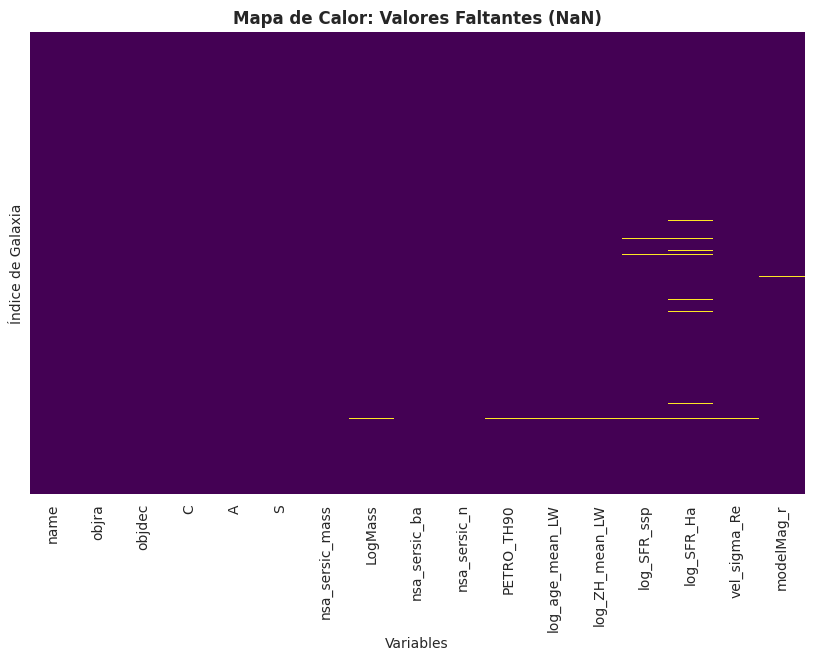

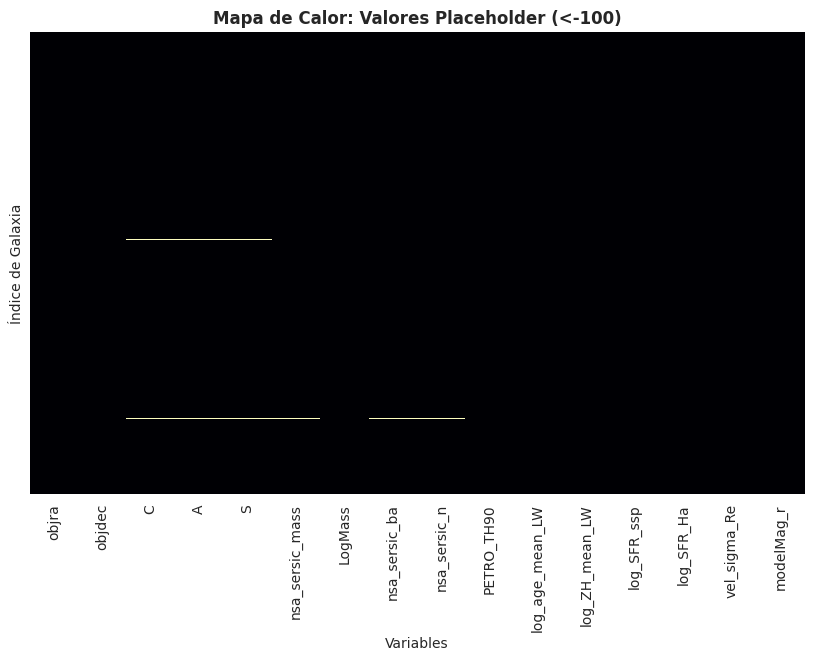


 Interpretación de los mapas de calor:
  - Áreas oscuras = datos presentes/válidos
  - Áreas claras/brillantes = datos faltantes/placeholder


In [8]:
# Visualización de valores faltantes y placeholders
if len(missing_data) > 0 or placeholder_report:

    # --- Gráfica 1: Mapa de calor de valores faltantes NaN ---
    plt.figure(figsize=(10, 6)) # Crea una ventana nueva
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Mapa de Calor: Valores Faltantes (NaN)', fontsize=12, fontweight='bold')
    plt.xlabel('Variables')
    plt.ylabel('Índice de Galaxia')
    plt.show() # Muestra la primera gráfica

    # --- Gráfica 2: Mapa de calor de valores placeholder ---
    plt.figure(figsize=(10, 6)) # Crea otra ventana nueva
    placeholder_mask_df = pd.DataFrame(
        {col: df[col] < -100 for col in numeric_cols}
    )

    sns.heatmap(placeholder_mask_df, cbar=False, yticklabels=False, cmap='magma')
    plt.title('Mapa de Calor: Valores Placeholder (<-100)', fontsize=12, fontweight='bold')
    plt.xlabel('Variables')
    plt.ylabel('Índice de Galaxia')
    plt.show() # Muestra la segunda gráfica

    print("\n Interpretación de los mapas de calor:")
    print("  - Áreas oscuras = datos presentes/válidos")
    print("  - Áreas claras/brillantes = datos faltantes/placeholder")
else:
    print("\n No se requiere visualización: dataset sin valores faltantes detectados.")

---

## 3. Estadísticas Descriptivas del Conjunto de Datos

### ¿Cuáles son las estadísticas resumidas del conjunto de datos?

Las estadísticas descriptivas nos proporcionan una comprensión cuantitativa de:
- Tendencia central (media, mediana)
- Dispersión (desviación estándar, rango)
- Forma de distribución (asimetría, curtosis)
- Valores extremos (mínimos, máximos)

In [9]:
# Estadísticas descriptivas básicas
print("\nESTADÍSTICAS DESCRIPTIVAS BÁSICAS:\n")
print("\n")
df.describe()


ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:





,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
count,10126.0000,10126.0000,10126.0000,10126.0000,10126.0000,1.0125e+04,10098.0000,10125.0000,10125.0000,10093.0000,10080.0000,10080.0000,10063.0000,9964.0000,10074.0000,10117.0000
mean,183.1383,28.6249,-0.0989,-3.1801,-3.2031,4.6741e+10,10.1618,-26.0640,-23.4262,15.4045,9.0625,-0.3590,-0.3124,-0.8551,0.3770,15.5701
std,76.3018,17.9684,57.9862,57.8048,57.8662,2.6602e+11,0.7189,515.7138,515.8539,10.5067,0.4203,0.2508,0.7135,1.2628,0.2003,1.0639
min,0.0088,-9.3024,-999.0000,-999.0000,-999.0000,-9.9990e+03,5.9125,-9999.0000,-9999.0000,0.2234,7.7808,-1.7387,-3.8305,-5.3752,-1.0000,11.4271
25%,128.8919,14.6527,2.8660,0.0840,0.0700,3.8402e+09,9.5899,0.4332,1.3808,9.3241,8.7192,-0.5195,-0.8196,-1.5960,0.2338,14.8240
50%,194.1075,29.3681,3.2240,0.1320,0.1600,1.5474e+10,10.1934,0.6281,2.8151,12.9932,9.0469,-0.3216,-0.2785,-0.5618,0.3744,15.6097
75%,239.6892,43.8665,3.6550,0.2180,0.3100,5.5613e+10,10.7481,0.7815,5.4566,18.5098,9.4258,-0.1647,0.2221,0.0763,0.5087,16.2270
max,359.8586,65.2897,5.5990,1.9710,8.6300,2.4568e+13,13.3904,1.0000,6.0000,148.0084,9.8770,0.1483,2.3041,3.8996,1.0850,24.8020


In [10]:
# Estadísticas extendidas: asimetría y curtosis
print("\nESTADÍSTICAS EXTENDIDAS (Asimetría y Curtosis):\n")
print("\n")

# Calcular estadísticas avanzadas para columnas numéricas
extended_stats = pd.DataFrame({
    'Media': df[numeric_cols].mean(),  # Promedio
    'Mediana': df[numeric_cols].median(),  # Valor central
    'Desv_Est': df[numeric_cols].std(),  # Dispersión
    'Asimetría': df[numeric_cols].apply(lambda x: skew(x.dropna())),  # Skewness
    'Curtosis': df[numeric_cols].apply(lambda x: kurtosis(x.dropna())),  # Kurtosis
    'Min': df[numeric_cols].min(),  # Mínimo
    'Max': df[numeric_cols].max()  # Máximo
})

# Redondear para mejor legibilidad
extended_stats = extended_stats.round(4)

print(extended_stats)
print("\n"*2)

# Interpretación de asimetría
print("\nInterpretación de Asimetría (Skewness):")
print("  - Asimetría ≈ 0: Distribución simétrica (normal)")
print("  - Asimetría > 0: Sesgada a la derecha (cola derecha larga)")
print("  - Asimetría < 0: Sesgada a la izquierda (cola izquierda larga)")
print("\nInterpretación de Curtosis:")
print("  - Curtosis ≈ 0: Forma similar a distribución normal")
print("  - Curtosis > 0: Más puntiaguda que la normal (leptocúrtica)")
print("  - Curtosis < 0: Más plana que la normal (platicúrtica)")


ESTADÍSTICAS EXTENDIDAS (Asimetría y Curtosis):



                      Media     Mediana    Desv_Est  Asimetría   Curtosis  \
objra            1.8314e+02  1.9411e+02  7.6302e+01    -0.1666    -0.0845   
objdec           2.8625e+01  2.9368e+01  1.7968e+01    -0.3165    -0.9638   
C               -9.8900e-02  3.2240e+00  5.7986e+01   -17.1670   292.7453   
A               -3.1801e+00  1.3200e-01  5.7805e+01   -17.1692   292.7974   
S               -3.2031e+00  1.6000e-01  5.7866e+01   -17.1160   291.5198   
nsa_sersic_mass  4.6741e+10  1.5474e+10  2.6602e+11    79.5959  7181.0124   
LogMass          1.0162e+01  1.0193e+01  7.1890e-01    -0.1774    -0.6043   
nsa_sersic_ba   -2.6064e+01  6.2810e-01  5.1571e+02   -19.2874   370.0025   
nsa_sersic_n    -2.3426e+01  2.8151e+00  5.1585e+02   -19.2869   369.9919   
PETRO_TH90       1.5405e+01  1.2993e+01  1.0507e+01     4.0298    29.8591   
log_age_mean_LW  9.0625e+00  9.0469e+00  4.2030e-01    -0.0378    -1.0094   
log_ZH_mean_LW  -3.5900e

---

## 4. Detección de Valores Atípicos (Outliers)

### ¿Hay valores atípicos en el conjunto de datos?

Los valores atípicos pueden:
- Ser errores de medición o entrada de datos
- Representar fenómenos genuinos pero raros
- Afectar significativamente modelos de ML

Utilizaremos dos métodos complementarios:
1. **Método IQR (Rango Intercuartílico)**: Define outliers como valores fuera de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
2. **Método Z-Score**: Identifica valores con más de 3 desviaciones estándar de la media

In [11]:
# Detección de outliers usando el método IQR
print("\nDETECCIÓN DE OUTLIERS - MÉTODO IQR (Rango Intercuartílico):\n")
print("\n")

# Crear DataFrame para almacenar resultados
outlier_summary_iqr = []

for col in numeric_cols:
    # Filtrar valores válidos (excluir placeholders)
    valid_data = df[col][df[col] > -100]

    # Calcular cuartiles
    Q1 = valid_data.quantile(0.25)  # Primer cuartil
    Q3 = valid_data.quantile(0.75)  # Tercer cuartil
    IQR = Q3 - Q1  # Rango intercuartílico

    # Definir límites para outliers
    lower_bound = Q1 - 1.5 * IQR  # Límite inferior
    upper_bound = Q3 + 1.5 * IQR  # Límite superior

    # Identificar outliers
    outliers_mask = (valid_data < lower_bound) | (valid_data > upper_bound)
    n_outliers = outliers_mask.sum()

    if n_outliers > 0:
        percentage = (n_outliers / len(valid_data)) * 100
        outlier_summary_iqr.append({
            'Columna': col,
            'N_Outliers': n_outliers,
            'Porcentaje': percentage,
            'Límite_Inferior': lower_bound,
            'Límite_Superior': upper_bound
        })

# Mostrar resultados
if outlier_summary_iqr:
    outlier_df_iqr = pd.DataFrame(outlier_summary_iqr)
    outlier_df_iqr = outlier_df_iqr.sort_values('Porcentaje', ascending=False)
    print(outlier_df_iqr.to_string(index=False))
    print("\n")
    print(f"\nTotal de variables con outliers: {len(outlier_summary_iqr)}")
else:
    print("No se detectaron outliers significativos usando el método IQR.")



DETECCIÓN DE OUTLIERS - MÉTODO IQR (Rango Intercuartílico):



        Columna  N_Outliers  Porcentaje  Límite_Inferior  Límite_Superior
              S         965      9.5639      -2.9000e-01       6.7000e-01
nsa_sersic_mass         892      8.8334      -7.4261e+10       1.3414e+11
              A         733      7.2632      -1.1600e-01       4.2000e-01
     PETRO_TH90         480      4.7558      -4.4545e+00       3.2288e+01
     log_SFR_Ha         168      1.6861      -4.1044e+00       2.5847e+00
              C         152      1.5061       1.6870e+00       4.8390e+00
     modelMag_r         115      1.1367       1.2719e+01       1.8332e+01
 log_ZH_mean_LW          90      0.8929      -1.0517e+00       3.6746e-01
   vel_sigma_Re          62      0.6154      -1.7848e-01       9.2103e-01
    log_SFR_ssp          18      0.1789      -2.3821e+00       1.7845e+00
        LogMass          12      0.1188       7.8527e+00       1.2485e+01



Total de variables con outliers: 11


In [12]:
# Detección de outliers usando Z-Score
print("\nDETECCIÓN DE OUTLIERS - MÉTODO Z-SCORE (|Z| > 3):\n")
print("\n")

outlier_summary_zscore = []

for col in numeric_cols:
    # Filtrar valores válidos
    valid_data = df[col][df[col] > -100]

    # Calcular Z-score
    z_scores = np.abs(stats.zscore(valid_data.dropna()))

    # Identificar outliers (|Z| > 3)
    n_outliers = (z_scores > 3).sum()

    if n_outliers > 0:
        percentage = (n_outliers / len(valid_data.dropna())) * 100
        outlier_summary_zscore.append({
            'Columna': col,
            'N_Outliers': n_outliers,
            'Porcentaje': percentage
        })

# Mostrar resultados
if outlier_summary_zscore:
    outlier_df_zscore = pd.DataFrame(outlier_summary_zscore)
    outlier_df_zscore = outlier_df_zscore.sort_values('Porcentaje', ascending=False)
    print(outlier_df_zscore.to_string(index=False))
    print("\n")
else:
    print("No se detectaron outliers extremos usando Z-Score > 3.")



DETECCIÓN DE OUTLIERS - MÉTODO Z-SCORE (|Z| > 3):



        Columna  N_Outliers  Porcentaje
     PETRO_TH90         169      1.6744
     modelMag_r          88      0.8698
              A          87      0.8621
              C          82      0.8125
 log_ZH_mean_LW          56      0.5556
     log_SFR_Ha          50      0.5018
   vel_sigma_Re          38      0.3772
              S          28      0.2775
    log_SFR_ssp          17      0.1689
        LogMass          14      0.1386
nsa_sersic_mass           9      0.0891
log_age_mean_LW           1      0.0099





VISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS:



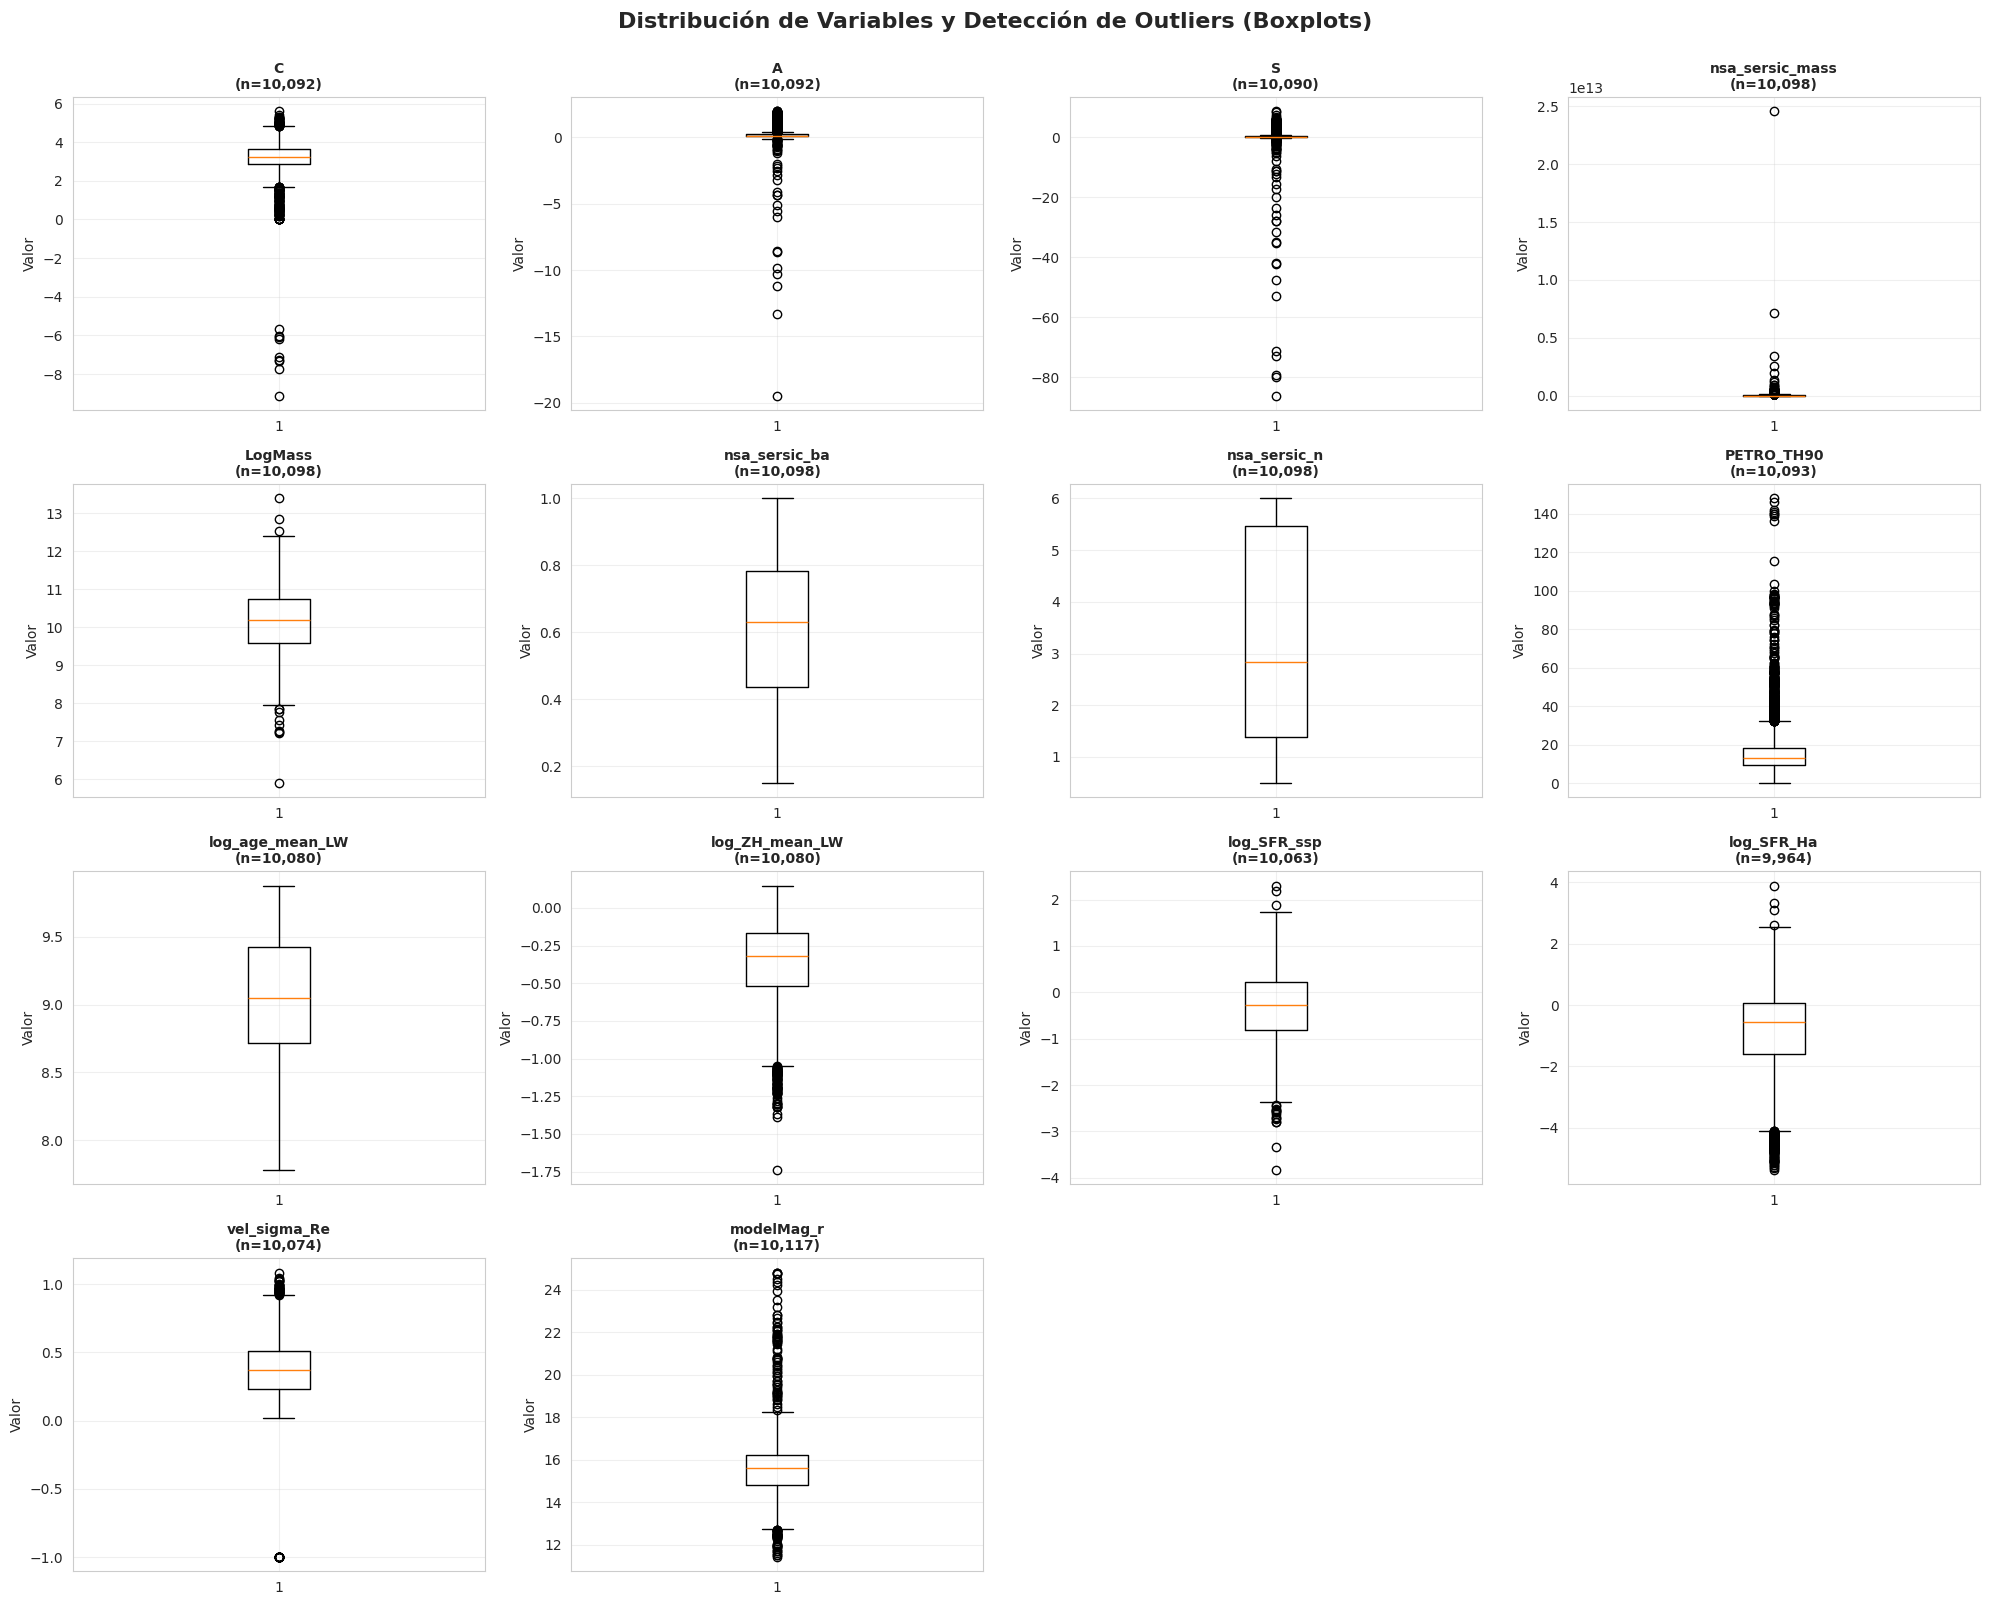


Interpretación de Boxplots:
  - Caja: Contiene el 50% central de los datos (Q1 a Q3)
  - Línea central: Mediana
  - Bigotes: Extienden hasta 1.5×IQR desde los cuartiles
  - Puntos fuera de bigotes: Outliers potenciales


In [13]:
# Visualización de outliers con boxplots
print("\nVISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS:\n")

# Seleccionar columnas clave para visualización (excluyendo coordenadas)
key_cols = [col for col in numeric_cols if col not in ['objra', 'objdec']]

# Crear subplots para boxplots
n_cols = 4  # Número de columnas en la cuadrícula
n_rows = int(np.ceil(len(key_cols) / n_cols))  # Calcular filas necesarias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()  # Aplanar array de axes para fácil iteración

for idx, col in enumerate(key_cols):
    # Filtrar datos válidos para la columna
    valid_data = df[col][df[col] > -100].dropna()

    # Crear boxplot
    axes[idx].boxplot(valid_data, vert=True)
    axes[idx].set_title(f'{col}\n(n={len(valid_data):,})', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3)

# Ocultar axes sobrantes
for idx in range(len(key_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribución de Variables y Detección de Outliers (Boxplots)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nInterpretación de Boxplots:")
print("  - Caja: Contiene el 50% central de los datos (Q1 a Q3)")
print("  - Línea central: Mediana")
print("  - Bigotes: Extienden hasta 1.5×IQR desde los cuartiles")
print("  - Puntos fuera de bigotes: Outliers potenciales")

---

## 5. Análisis de Cardinalidad de Variables Categóricas

### ¿Cuál es la cardinalidad de las variables categóricas?

La cardinalidad (número de valores únicos) de variables categóricas es importante porque:
- Alta cardinalidad puede causar problemas en encoding
- Puede indicar si una variable es útil para clasificación/agrupación
- Afecta la complejidad computacional del modelo

In [20]:
# Análisis de cardinalidad
print("\nANÁLISIS DE CARDINALIDAD:\n")

# Identificar columnas categóricas (tipo object o string)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    cardinality_report = pd.DataFrame({
        'Columna': categorical_cols,
        'Valores_Únicos': [df[col].nunique() for col in categorical_cols],
        'Cardinalidad_%': [(df[col].nunique() / len(df)) * 100 for col in categorical_cols]
    })

    cardinality_report = cardinality_report.sort_values('Valores_Únicos', ascending=False)
    print(cardinality_report.to_string(index=False))

    # Clasificación de cardinalidad
    print("\nClasificación de Cardinalidad:")
    for _, row in cardinality_report.iterrows():
        col = row['Columna']
        card = row['Valores_Únicos']

        if card == len(df):
            category = "IDENTIFICADOR ÚNICO"
        elif card > len(df) * 0.5:
            category = "CARDINALIDAD MUY ALTA"
        elif card > 50:
            category = "CARDINALIDAD ALTA"
        elif card > 10:
            category = "CARDINALIDAD MEDIA"
        else:
            category = "CARDINALIDAD BAJA"

        print(f"  - {col}: {card:,} valores únicos - {category}")
else:
    print("No se detectaron variables categóricas (tipo object) en el dataset.")
    print("El dataset contiene principalmente variables numéricas.")
    print("\n\n")

# Análisis de la variable 'name' (identificador)
print("\n\n\nANÁLISIS DE IDENTIFICADORES (columna 'name'):\n")
print(f"Total de galaxias: {len(df):,}")
print(f"IDs únicos: {df['name'].nunique():,}")
print(f"IDs duplicados: {len(df) - df['name'].nunique():,}")

if df['name'].nunique() == len(df):
    print("\nCada galaxia tiene un identificador único.")
else:
    print("\nHay IDs duplicados en el dataset.")
    duplicates = df[df.duplicated(subset=['name'], keep=False)]
    print(f"   Registros duplicados: {len(duplicates):,}")



ANÁLISIS DE CARDINALIDAD:

Columna  Valores_Únicos  Cardinalidad_%
   name           10126           100.0

Clasificación de Cardinalidad:
  - name: 10,126 valores únicos - IDENTIFICADOR ÚNICO



ANÁLISIS DE IDENTIFICADORES (columna 'name'):

Total de galaxias: 10,126
IDs únicos: 10,126
IDs duplicados: 0

Cada galaxia tiene un identificador único.


---

## 6. Análisis de Distribuciones y Transformaciones

### ¿Existen distribuciones sesgadas? ¿Necesitamos aplicar transformaciones no lineales?

Muchos algoritmos de ML asumen distribuciones aproximadamente normales. Transformaciones como:
- **Log**: Para reducir asimetría positiva
- **Box-Cox**: Para normalizar distribuciones
- **Escalado**: Para poner variables en rangos comparables

pueden mejorar significativamente el rendimiento del modelo.


ANÁLISIS DE DISTRIBUCIONES (Histogramas):



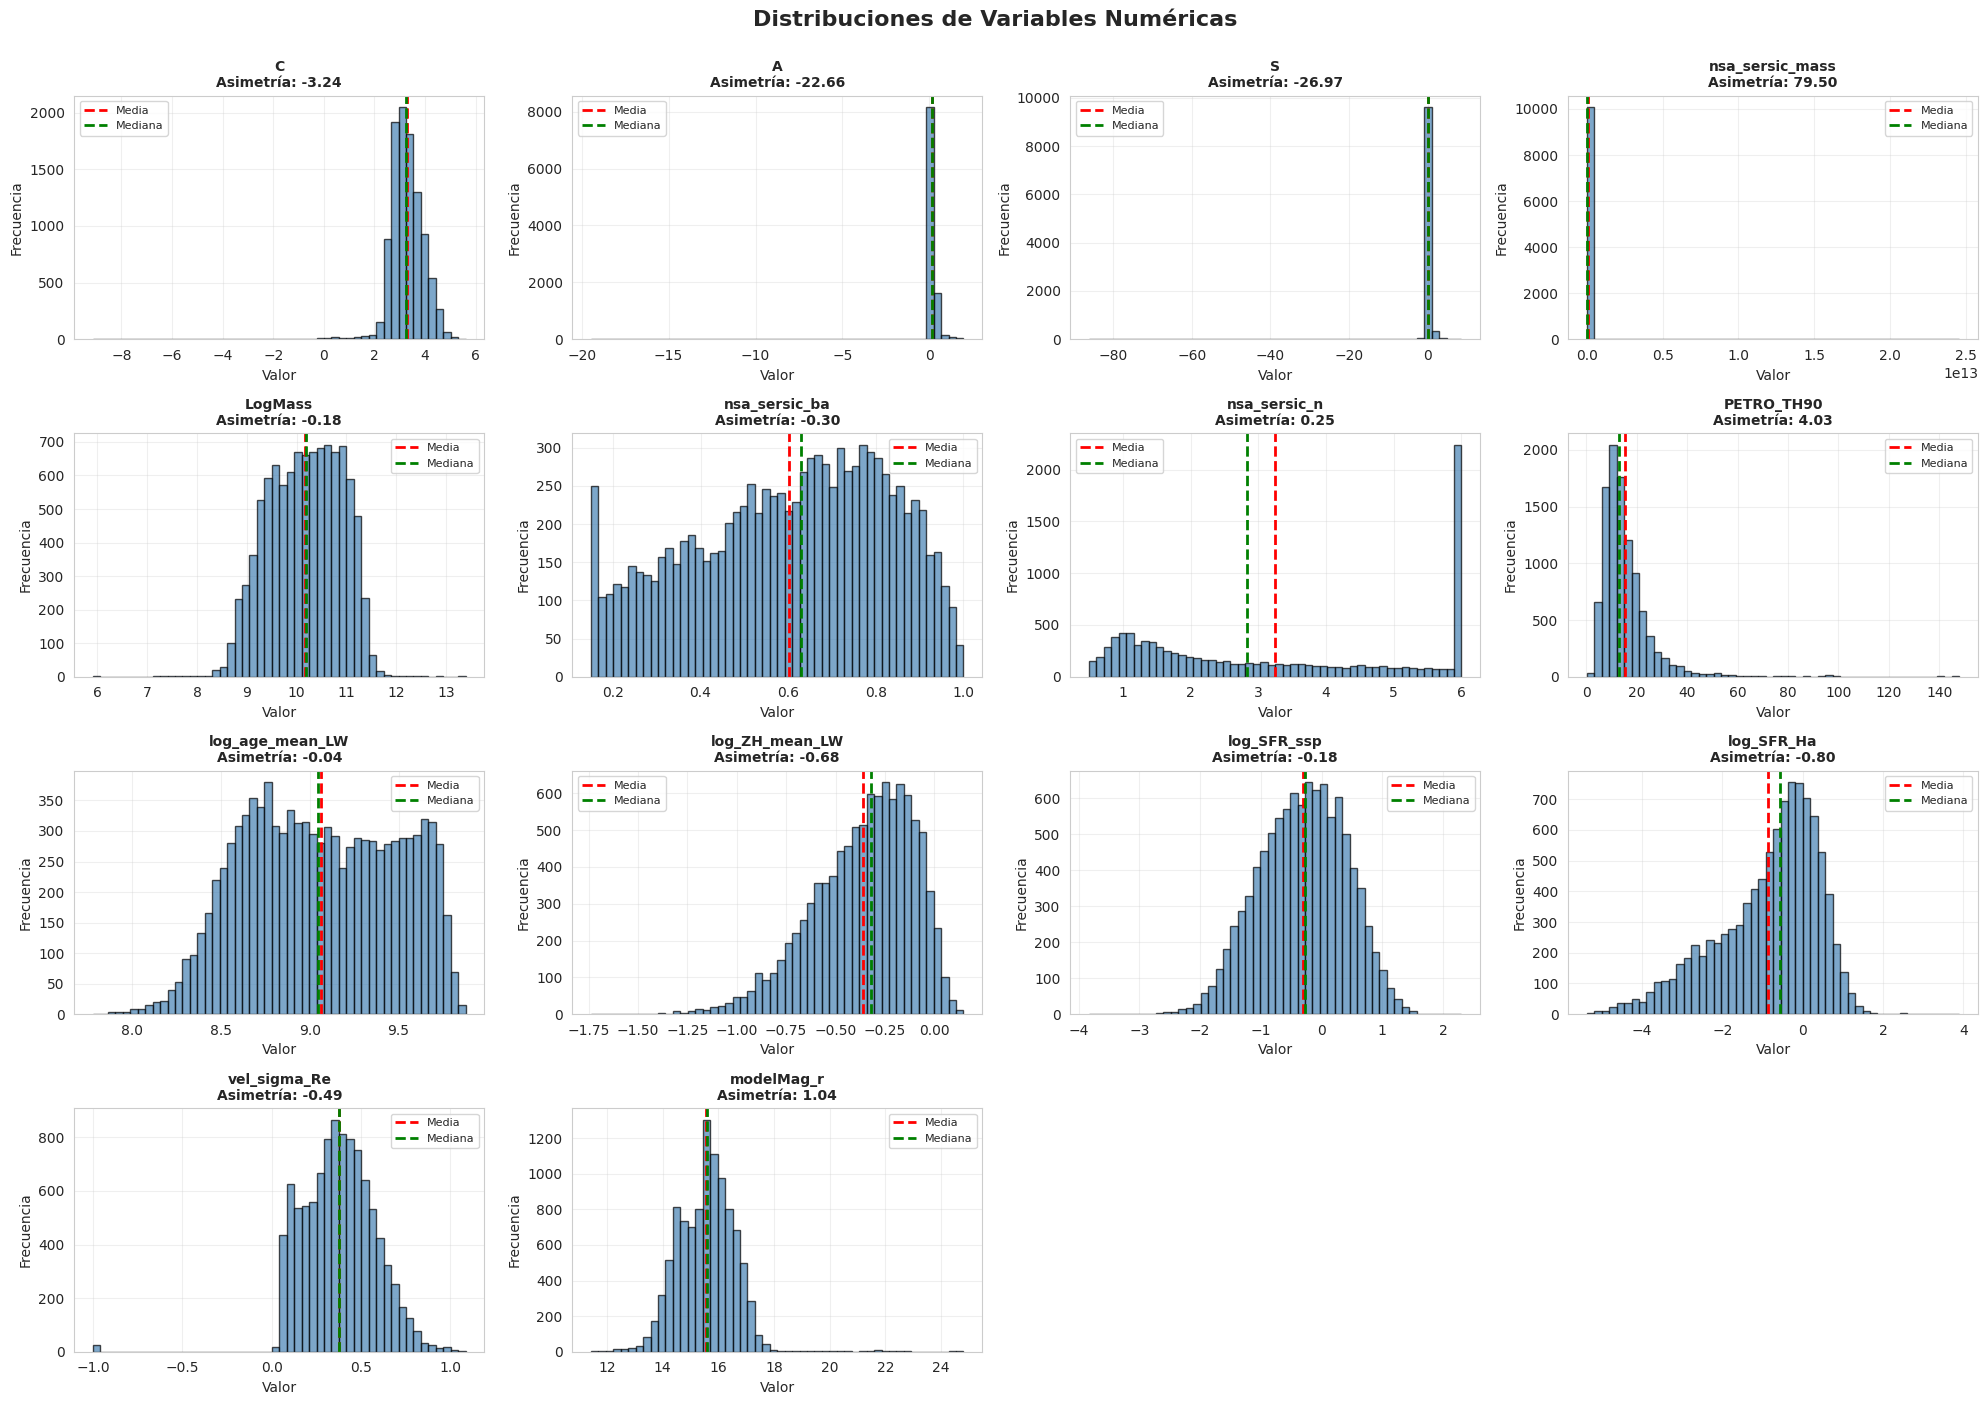


Interpretación de Asimetría en los Histogramas:
  - Asimetría ≈ 0: Distribución simétrica (líneas roja y verde coinciden)
  - Asimetría > 1: Fuertemente sesgada a la derecha
  - Asimetría < -1: Fuertemente sesgada a la izquierda


In [21]:
# Visualización de distribuciones con histogramas
print("\nANÁLISIS DE DISTRIBUCIONES (Histogramas):\n")

# Seleccionar columnas clave (excluyendo coordenadas)
dist_cols = [col for col in numeric_cols if col not in ['objra', 'objdec']]

# Configurar subplots
n_cols_grid = 4
n_rows_grid = int(np.ceil(len(dist_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3.5))
axes = axes.flatten()

for idx, col in enumerate(dist_cols):
    # Filtrar datos válidos
    valid_data = df[col][df[col] > -100].dropna()

    # Calcular asimetría
    skewness = skew(valid_data)

    # Crear histograma
    axes[idx].hist(valid_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].axvline(valid_data.mean(), color='red', linestyle='--', linewidth=2, label='Media')
    axes[idx].axvline(valid_data.median(), color='green', linestyle='--', linewidth=2, label='Mediana')

    # Título con información de asimetría
    axes[idx].set_title(f'{col}\nAsimetría: {skewness:.2f}', fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Ocultar axes sobrantes
for idx in range(len(dist_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nInterpretación de Asimetría en los Histogramas:")
print("  - Asimetría ≈ 0: Distribución simétrica (líneas roja y verde coinciden)")
print("  - Asimetría > 1: Fuertemente sesgada a la derecha")
print("  - Asimetría < -1: Fuertemente sesgada a la izquierda")

In [23]:
# Identificar variables que requieren transformación
print("\nRECOMENDACIONES DE TRANSFORMACIÓN:\n")
print("\n")

transformation_needed = []

for col in dist_cols:
    valid_data = df[col][df[col] > -100].dropna()
    skewness = skew(valid_data)

    # Criterio: asimetría absoluta > 1 sugiere necesidad de transformación
    if abs(skewness) > 1:
        if skewness > 1:
            recommendation = "Transformación logarítmica (log) o Box-Cox"
            reason = "Asimetría positiva fuerte (cola derecha)"
        else:
            recommendation = "Transformación exponencial o reflexión + log"
            reason = "Asimetría negativa fuerte (cola izquierda)"

        transformation_needed.append({
            'Variable': col,
            'Asimetría': round(skewness, 3),
            'Razón': reason,
            'Transformación_Sugerida': recommendation
        })

if transformation_needed:
    trans_df = pd.DataFrame(transformation_needed)
    trans_df = trans_df.sort_values('Asimetría', key=abs, ascending=False)

    for _, row in trans_df.iterrows():
        print(f"Variable: {row['Variable']}")
        print(f"  Asimetría: {row['Asimetría']}")
        print(f"  Razón: {row['Razón']}")
        print(f"  Transformación sugerida: {row['Transformación_Sugerida']}")
        print()


    print(f"\n\nTotal de variables que requieren transformación: {len(transformation_needed)}")
else:
    print("Todas las variables presentan distribuciones aceptablemente simétricas.")
    print("No se requieren transformaciones obligatorias.")




RECOMENDACIONES DE TRANSFORMACIÓN:



Variable: nsa_sersic_mass
  Asimetría: 79.498
  Razón: Asimetría positiva fuerte (cola derecha)
  Transformación sugerida: Transformación logarítmica (log) o Box-Cox

Variable: S
  Asimetría: -26.974
  Razón: Asimetría negativa fuerte (cola izquierda)
  Transformación sugerida: Transformación exponencial o reflexión + log

Variable: A
  Asimetría: -22.66
  Razón: Asimetría negativa fuerte (cola izquierda)
  Transformación sugerida: Transformación exponencial o reflexión + log

Variable: PETRO_TH90
  Asimetría: 4.03
  Razón: Asimetría positiva fuerte (cola derecha)
  Transformación sugerida: Transformación logarítmica (log) o Box-Cox

Variable: C
  Asimetría: -3.244
  Razón: Asimetría negativa fuerte (cola izquierda)
  Transformación sugerida: Transformación exponencial o reflexión + log

Variable: modelMag_r
  Asimetría: 1.044
  Razón: Asimetría positiva fuerte (cola derecha)
  Transformación sugerida: Transformación logarítmica (log) o Box-Cox




---

## 7. Análisis de Correlación

### ¿Hay correlación entre las variables?

El análisis de correlación nos ayuda a:
- Identificar relaciones lineales entre variables
- Detectar multicolinealidad (variables altamente correlacionadas)
- Seleccionar features relevantes para el modelo
- Comprender relaciones físicas entre propiedades de galaxias


MATRIZ DE CORRELACIÓN DE PEARSON:



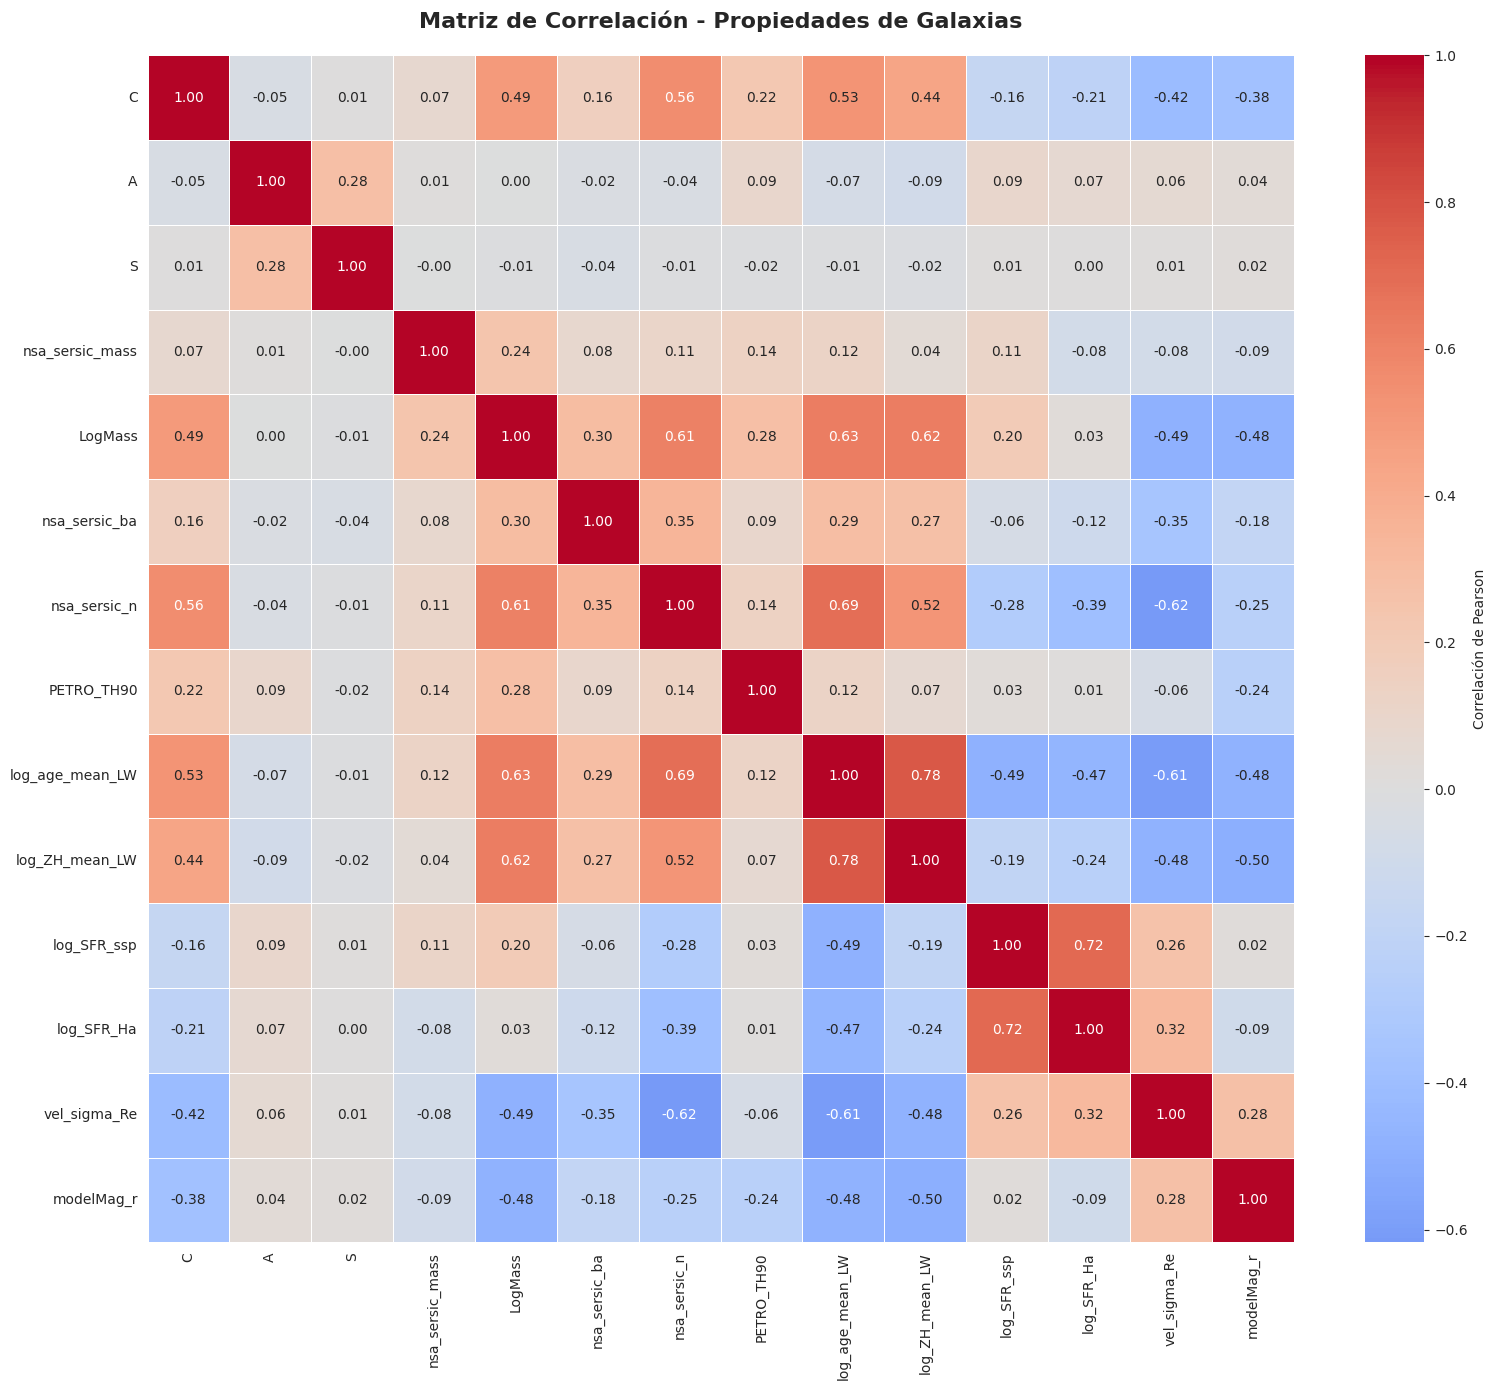


Interpretación de Correlación de Pearson:
  - Correlación = +1: Relación lineal positiva perfecta
  - Correlación = 0: Sin relación lineal
  - Correlación = -1: Relación lineal negativa perfecta
  - |Correlación| > 0.7: Correlación fuerte
  - |Correlación| > 0.5: Correlación moderada
  - |Correlación| < 0.3: Correlación débil


In [24]:
# Calcular matriz de correlación (excluyendo placeholders)
print("\nMATRIZ DE CORRELACIÓN DE PEARSON:\n")

# Crear una copia limpia del dataframe sin placeholders
df_clean = df.copy()
for col in numeric_cols:
    df_clean.loc[df_clean[col] < -100, col] = np.nan

# Seleccionar solo columnas numéricas para correlación (excluyendo coordenadas)
corr_cols = [col for col in numeric_cols if col not in ['objra', 'objdec']]
correlation_matrix = df_clean[corr_cols].corr()

# Visualizar matriz de correlación con heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de Correlación - Propiedades de Galaxias', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nInterpretación de Correlación de Pearson:")
print("  - Correlación = +1: Relación lineal positiva perfecta")
print("  - Correlación = 0: Sin relación lineal")
print("  - Correlación = -1: Relación lineal negativa perfecta")
print("  - |Correlación| > 0.7: Correlación fuerte")
print("  - |Correlación| > 0.5: Correlación moderada")
print("  - |Correlación| < 0.3: Correlación débil")

In [27]:
# Identificar pares de variables altamente correlacionadas
print("\nPARES DE VARIABLES CON ALTA CORRELACIÓN (|r| > 0.7):\n")

# Extraer pares con correlación alta
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Variable_1': correlation_matrix.columns[i],
                'Variable_2': correlation_matrix.columns[j],
                'Correlación': round(corr_value, 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlación', key=abs, ascending=False)

    print(high_corr_df.to_string(index=False))
    print("\n")
    print(f"\nTotal de pares con alta correlación: {len(high_corr_pairs)}")

    print("\nIMPLICACIONES:")
    print("  - Alta correlación puede indicar multicolinealidad")
    print("  - Considerar eliminar una de las variables del par para reducir redundancia")
    print("  - O aplicar técnicas de reducción de dimensionalidad (PCA, etc.)")
else:
    print("No se detectaron pares de variables con correlación > 0.7")
    print("Las variables son relativamente independientes entre sí.")


PARES DE VARIABLES CON ALTA CORRELACIÓN (|r| > 0.7):

     Variable_1     Variable_2  Correlación
log_age_mean_LW log_ZH_mean_LW        0.775
    log_SFR_ssp     log_SFR_Ha        0.716



Total de pares con alta correlación: 2

IMPLICACIONES:
  - Alta correlación puede indicar multicolinealidad
  - Considerar eliminar una de las variables del par para reducir redundancia
  - O aplicar técnicas de reducción de dimensionalidad (PCA, etc.)
